<a href="https://colab.research.google.com/github/aoibhinmwalsh/MSc_Project_Renewable_Energy_Forecasting/blob/main/MSc_Project_AW_Notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Renewable Energy Forecasting - HadUK and NESO Datasets

In [ ]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Reading in Datasets

In [ ]:
#need this library to read in nc files from met office
!pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.8 MB/s eta 0:00:00


In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns

## Tas (temperature) - Met Office UK

In [ ]:
#monthly average of temperatures
ds = xr.open_dataset("/content/drive/MyDrive/diss/tas_hadukgrid_uk_country_mon_188401-202412.nc")
df_tas = ds.to_dataframe().reset_index()
df_tas.head()

,time,region,bnds,tas,time_bnds,geo_region,calendar_year,month_number,season_year
0,1884-01-16,1,0,NaN,1884-01-01,b'Channel Islands ',1884,1,1884
1,1884-01-16,1,1,NaN,1884-02-01,b'Channel Islands ',1884,1,1884
2,1884-01-16,2,0,5.71331,1884-01-01,b'England ',1884,1,1884
3,1884-01-16,2,1,5.71331,1884-02-01,b'England ',1884,1,1884
4,1884-01-16,3,0,5.72211,1884-01-01,b'England and Wales',1884,1,1884


In [ ]:
df_tas.shape

(27072, 9)

In [ ]:
#just want united kingdom entry not scotland, england etc.
df_tas = df_tas[df_tas['geo_region'].astype(str).str.contains('United Kingdom')]

In [ ]:
df_tas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3384 entries, 12 to 27069
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           3384 non-null   datetime64[ns]
 1   region         3384 non-null   int64         
 2   bnds           3384 non-null   int64         
 3   tas            3384 non-null   float64       
 4   time_bnds      3384 non-null   datetime64[ns]
 5   geo_region     3384 non-null   object        
 6   calendar_year  3384 non-null   int64         
 7   month_number   3384 non-null   int64         
 8   season_year    3384 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(5), object(1)
memory usage: 264.4+ KB


In [ ]:
df_tas.describe()

,time,region,bnds,tas,time_bnds,calendar_year,month_number,season_year
count,3384,3384.0,3384.000000,3384.000000,3384,3384.000000,3384.000000,3384.000000
mean,1954-07-01 16:47:39.574468032,7.0,0.500000,8.465190,1954-07-01 22:02:33.191489344,1954.000000,6.500000,1954.083333
min,1884-01-16 00:00:00,7.0,0.000000,-2.301220,1884-01-01 00:00:00,1884.000000,1.000000,1884.000000
25%,1919-04-08 06:00:00,7.0,0.000000,4.772018,1919-04-01 00:00:00,1919.000000,3.750000,1919.000000
50%,1954-07-01 00:00:00,7.0,0.500000,8.139375,1954-07-01 00:00:00,1954.000000,6.500000,1954.000000
75%,1989-09-23 12:00:00,7.0,1.000000,12.611923,1989-10-01 00:00:00,1989.000000,9.250000,1989.000000
max,2024-12-16 00:00:00,7.0,1.000000,17.814370,2025-01-01 00:00:00,2024.000000,12.000000,2025.000000
std,NaN,0.0,0.500074,4.347944,NaN,40.708186,3.452563,40.709124


In [ ]:
df_tas.head()

,time,region,bnds,tas,time_bnds,geo_region,calendar_year,month_number,season_year
12,1884-01-16,7,0,5.00992,1884-01-01,b'United Kingdom ',1884,1,1884
13,1884-01-16,7,1,5.00992,1884-02-01,b'United Kingdom ',1884,1,1884
28,1884-02-16,7,0,4.15717,1884-02-01,b'United Kingdom ',1884,2,1884
29,1884-02-16,7,1,4.15717,1884-03-01,b'United Kingdom ',1884,2,1884
44,1884-03-16,7,0,5.09953,1884-03-01,b'United Kingdom ',1884,3,1884


In [ ]:
#removing duplicates of each month (there was time band 0 and 1 but had the same average temperature reading)
df_tas = df_tas.drop_duplicates(subset='time', keep='first')

In [ ]:
#retained time band 0
df_tas.head()

,time,region,bnds,tas,time_bnds,geo_region,calendar_year,month_number,season_year
12,1884-01-16,7,0,5.00992,1884-01-01,b'United Kingdom ',1884,1,1884
28,1884-02-16,7,0,4.15717,1884-02-01,b'United Kingdom ',1884,2,1884
44,1884-03-16,7,0,5.09953,1884-03-01,b'United Kingdom ',1884,3,1884
60,1884-04-16,7,0,6.16371,1884-04-01,b'United Kingdom ',1884,4,1884
76,1884-05-16,7,0,9.66388,1884-05-01,b'United Kingdom ',1884,5,1884


In [ ]:
df_tas.describe()

,time,region,bnds,tas,time_bnds,calendar_year,month_number,season_year
count,1692,1692.0,1692.0,1692.000000,1692,1692.000000,1692.000000,1692.000000
mean,1954-07-01 16:47:39.574468032,7.0,0.0,8.465190,1954-06-16 16:47:39.574468032,1954.000000,6.500000,1954.083333
min,1884-01-16 00:00:00,7.0,0.0,-2.301220,1884-01-01 00:00:00,1884.000000,1.000000,1884.000000
25%,1919-04-08 06:00:00,7.0,0.0,4.772018,1919-03-24 06:00:00,1919.000000,3.750000,1919.000000
50%,1954-07-01 00:00:00,7.0,0.0,8.139375,1954-06-16 00:00:00,1954.000000,6.500000,1954.000000
75%,1989-09-23 12:00:00,7.0,0.0,12.611923,1989-09-08 12:00:00,1989.000000,9.250000,1989.000000
max,2024-12-16 00:00:00,7.0,0.0,17.814370,2024-12-01 00:00:00,2024.000000,12.000000,2025.000000
std,NaN,0.0,0.0,4.348587,NaN,40.714203,3.453073,40.715142


In [ ]:
df_tas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1692 entries, 12 to 27068
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           1692 non-null   datetime64[ns]
 1   region         1692 non-null   int64         
 2   bnds           1692 non-null   int64         
 3   tas            1692 non-null   float64       
 4   time_bnds      1692 non-null   datetime64[ns]
 5   geo_region     1692 non-null   object        
 6   calendar_year  1692 non-null   int64         
 7   month_number   1692 non-null   int64         
 8   season_year    1692 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(5), object(1)
memory usage: 132.2+ KB


##Tasmin - Met Office UK

In [ ]:
#minium temperature of each month
ds = xr.open_dataset("/content/drive/MyDrive/diss/tasmin_hadukgrid_uk_country_mon_188401-202412.nc")
df_tasmin = ds.to_dataframe().reset_index()
df_tasmin.head()

,time,region,bnds,tasmin,time_bnds,geo_region,calendar_year,month_number,season_year
0,1884-01-16,1,0,NaN,1884-01-01,b'Channel Islands ',1884,1,1884
1,1884-01-16,1,1,NaN,1884-02-01,b'Channel Islands ',1884,1,1884
2,1884-01-16,2,0,3.27763,1884-01-01,b'England ',1884,1,1884
3,1884-01-16,2,1,3.27763,1884-02-01,b'England ',1884,1,1884
4,1884-01-16,3,0,3.32986,1884-01-01,b'England and Wales',1884,1,1884


In [ ]:
#just want united kingdom entry not scotland, england etc.
df_tasmin = df_tasmin[df_tasmin['geo_region'].astype(str).str.contains('United Kingdom')]

In [ ]:
#removing duplicates again, same as av temp
df_tasmin = df_tasmin.drop_duplicates(subset='time', keep='first')

##Tasmax - Met Office UK

In [ ]:
#maximum temperature of each month
ds = xr.open_dataset("/content/drive/MyDrive/diss/tasmax_hadukgrid_uk_country_mon_188401-202412.nc")
df_tasmax = ds.to_dataframe().reset_index()
df_tasmax.head()

,time,region,bnds,tasmax,time_bnds,geo_region,calendar_year,month_number,season_year
0,1884-01-16,1,0,NaN,1884-01-01,b'Channel Islands ',1884,1,1884
1,1884-01-16,1,1,NaN,1884-02-01,b'Channel Islands ',1884,1,1884
2,1884-01-16,2,0,8.17208,1884-01-01,b'England ',1884,1,1884
3,1884-01-16,2,1,8.17208,1884-02-01,b'England ',1884,1,1884
4,1884-01-16,3,0,8.13940,1884-01-01,b'England and Wales',1884,1,1884


In [ ]:
#just want united kingdom entry not scotland, england etc.
df_tasmax = df_tasmax[df_tasmax['geo_region'].astype(str).str.contains('United Kingdom')]

In [ ]:
#removing duplicates
df_tasmax = df_tasmax.drop_duplicates(subset='time', keep='first')

## Rain - Met Office UK

In [ ]:
#average rainfall of each month
ds_rain = xr.open_dataset("/content/drive/MyDrive/diss/rainfall_hadukgrid_uk_country_mon_183601-202412.nc")
df_rain = ds_rain.to_dataframe().reset_index()
df_rain.head()

,time,region,bnds,rainfall,time_bnds,geo_region,calendar_year,month_number,season_year
0,1836-01-16,1,0,NaN,1836-01-01 09:00:00,b'Channel Islands ',1836,1,1836
1,1836-01-16,1,1,NaN,1836-02-01 09:00:00,b'Channel Islands ',1836,1,1836
2,1836-01-16,2,0,65.04211,1836-01-01 09:00:00,b'England ',1836,1,1836
3,1836-01-16,2,1,65.04211,1836-02-01 09:00:00,b'England ',1836,1,1836
4,1836-01-16,3,0,72.62611,1836-01-01 09:00:00,b'England and Wales',1836,1,1836


In [ ]:
df_rain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36288 entries, 0 to 36287
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           36288 non-null  datetime64[ns]
 1   region         36288 non-null  int64         
 2   bnds           36288 non-null  int64         
 3   rainfall       31752 non-null  float64       
 4   time_bnds      36288 non-null  datetime64[ns]
 5   geo_region     36288 non-null  object        
 6   calendar_year  36288 non-null  int64         
 7   month_number   36288 non-null  int64         
 8   season_year    36288 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(5), object(1)
memory usage: 2.5+ MB


In [ ]:
df_rain.describe()

,time,region,bnds,rainfall,time_bnds,calendar_year,month_number,season_year
count,36288,36288.000000,36288.000000,31752.000000,36288,36288.000000,36288.0000,36288.000000
mean,1930-07-01 22:10:47.619047168,4.500000,0.500000,93.373654,1930-07-02 12:25:42.857142528,1930.000000,6.5000,1930.083333
min,1836-01-16 00:00:00,1.000000,0.000000,2.360810,1836-01-01 09:00:00,1836.000000,1.0000,1836.000000
25%,1883-04-08 06:00:00,2.750000,0.000000,59.721452,1883-04-01 09:00:00,1883.000000,3.7500,1883.000000
50%,1930-07-01 00:00:00,4.500000,0.500000,86.300995,1930-07-01 09:00:00,1930.000000,6.5000,1930.000000
75%,1977-09-23 12:00:00,6.250000,1.000000,119.486833,1977-10-01 09:00:00,1977.000000,9.2500,1977.000000
max,2024-12-16 00:00:00,8.000000,1.000000,333.004660,2025-01-01 09:00:00,2024.000000,12.0000,2025.000000
std,NaN,2.291319,0.500007,46.948964,NaN,54.559589,3.4521,54.560289


In [ ]:
#just want united kingdom entry not scotland, england etc.
df_rain = df_rain[df_rain['geo_region'].astype(str).str.contains('United Kingdom')]

In [ ]:
#remomving duplicates
df_rain = df_rain.drop_duplicates(subset='time', keep='first')

In [ ]:
df_rain.shape

(2268, 9)

## Sun - Met Office UK

In [ ]:
#average sunlight hours per month
ds_sun = xr.open_dataset("/content/drive/MyDrive/diss/sun_hadukgrid_uk_country_mon_191001-202412.nc")
df_sun = ds_sun.to_dataframe().reset_index()
df_sun.head()

,time,region,bnds,sun,time_bnds,geo_region,calendar_year,month_number,season_year
0,1910-01-16,1,0,NaN,1910-01-01,b'Channel Islands ',1910,1,1910
1,1910-01-16,1,1,NaN,1910-02-01,b'Channel Islands ',1910,1,1910
2,1910-01-16,2,0,59.64847,1910-01-01,b'England ',1910,1,1910
3,1910-01-16,2,1,59.64847,1910-02-01,b'England ',1910,1,1910
4,1910-01-16,3,0,58.01989,1910-01-01,b'England and Wales',1910,1,1910


In [ ]:
df_sun.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22080 entries, 0 to 22079
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           22080 non-null  datetime64[ns]
 1   region         22080 non-null  int64         
 2   bnds           22080 non-null  int64         
 3   sun            19320 non-null  float64       
 4   time_bnds      22080 non-null  datetime64[ns]
 5   geo_region     22080 non-null  object        
 6   calendar_year  22080 non-null  int64         
 7   month_number   22080 non-null  int64         
 8   season_year    22080 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(5), object(1)
memory usage: 1.5+ MB


In [ ]:
df_sun.describe()

,time,region,bnds,sun,time_bnds,calendar_year,month_number,season_year
count,22080,22080.00000,22080.000000,19320.000000,22080,22080.000000,22080.000000,22080.000000
mean,1967-07-01 19:57:54.782608688,4.50000,0.500000,114.462357,1967-07-02 01:13:02.608695648,1967.000000,6.500000,1967.083333
min,1910-01-16 00:00:00,1.00000,0.000000,10.510150,1910-01-01 00:00:00,1910.000000,1.000000,1910.000000
25%,1938-10-08 12:00:00,2.75000,0.000000,61.420088,1938-10-01 00:00:00,1938.000000,3.750000,1938.000000
50%,1967-07-01 00:00:00,4.50000,0.500000,110.181145,1967-07-01 00:00:00,1967.000000,6.500000,1967.000000
75%,1996-03-23 18:00:00,6.25000,1.000000,158.076345,1996-04-01 00:00:00,1996.000000,9.250000,1996.000000
max,2024-12-16 00:00:00,8.00000,1.000000,322.426310,2025-01-01 00:00:00,2024.000000,12.000000,2025.000000
std,NaN,2.29134,0.500011,58.958977,NaN,33.197137,3.452131,33.198288


In [ ]:
#just want united kingdom entry not scotland, england etc.
df_sun = df_sun[df_sun['geo_region'].astype(str).str.contains('United Kingdom')]

In [ ]:
#removing duplicates
df_sun = df_sun.drop_duplicates(subset='time', keep='first')

In [ ]:
df_sun.shape

(1380, 9)

## Wind - Met Office UK

In [ ]:
#average windspeed per month
ds_wind = xr.open_dataset("/content/drive/MyDrive/diss/sfcWind_hadukgrid_uk_country_mon_196901-202412.nc")
df_wind = ds_wind.to_dataframe().reset_index()
df_wind.head(30)

,time,region,bnds,sfcWind,time_bnds,geo_region,calendar_year,month_number,season_year
0,1969-01-16,1,0,NaN,1969-01-01,b'Channel Islands ',1969,1,1969
1,1969-01-16,1,1,NaN,1969-02-01,b'Channel Islands ',1969,1,1969
2,1969-01-16,2,0,4.850851,1969-01-01,b'England ',1969,1,1969
3,1969-01-16,2,1,4.850851,1969-02-01,b'England ',1969,1,1969
4,1969-01-16,3,0,4.984061,1969-01-01,b'England and Wales',1969,1,1969
5,1969-01-16,3,1,4.984061,1969-02-01,b'England and Wales',1969,1,1969
6,1969-01-16,4,0,8.342468,1969-01-01,b'Isle of Man ',1969,1,1969
7,1969-01-16,4,1,8.342468,1969-02-01,b'Isle of Man ',1969,1,1969
8,1969-01-16,5,0,4.997833,1969-01-01,b'Northern Ireland ',1969,1,1969
9,1969-01-16,5,1,4.997833,1969-02-01,b'Northern Ireland ',1969,1,1969


In [ ]:
df_wind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10752 entries, 0 to 10751
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           10752 non-null  datetime64[ns]
 1   region         10752 non-null  int64         
 2   bnds           10752 non-null  int64         
 3   sfcWind        9408 non-null   float64       
 4   time_bnds      10752 non-null  datetime64[ns]
 5   geo_region     10752 non-null  object        
 6   calendar_year  10752 non-null  int64         
 7   month_number   10752 non-null  int64         
 8   season_year    10752 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(5), object(1)
memory usage: 756.1+ KB


In [ ]:
df_wind.describe()

,time,region,bnds,sfcWind,time_bnds,calendar_year,month_number,season_year
count,10752,10752.000000,10752.000000,9408.000000,10752,10752.000000,10752.000000,10752.000000
mean,1996-12-30 17:00:00,4.500000,0.500000,5.228820,1996-12-30 22:14:59.999999872,1996.500000,6.500000,1996.583333
min,1969-01-16 00:00:00,1.000000,0.000000,2.701811,1969-01-01 00:00:00,1969.000000,1.000000,1969.000000
25%,1983-01-08 06:00:00,2.750000,0.000000,4.177685,1983-01-01 00:00:00,1982.750000,3.750000,1983.000000
50%,1996-12-31 12:00:00,4.500000,0.500000,4.864381,1997-01-01 00:00:00,1996.500000,6.500000,1997.000000
75%,2010-12-23 18:00:00,6.250000,1.000000,5.869352,2011-01-01 00:00:00,2010.250000,9.250000,2011.000000
max,2024-12-16 00:00:00,8.000000,1.000000,14.238742,2025-01-01 00:00:00,2024.000000,12.000000,2025.000000
std,NaN,2.291394,0.500023,1.500159,NaN,16.163982,3.452213,16.166345


In [ ]:
#just want united kingdom entry not scotland, england etc.
df_wind = df_wind[df_wind['geo_region'].astype(str).str.contains('United Kingdom')]

In [ ]:
#removing duplicates
df_wind = df_wind.drop_duplicates(subset='time', keep='first')

In [ ]:
df_wind.shape

(672, 9)

## Matching up these datasets by time index

In [ ]:
#set time as the index for each variables df so they align when merged
df_tas = df_tas.set_index('time')
df_sun = df_sun.set_index('time')
df_rainfall = df_rain.set_index('time')
df_sfcWind  = df_wind.set_index('time')
df_tasmin = df_tasmin.set_index('time')
df_tasmax = df_tasmax.set_index('time')

merged = df_tas.copy()

#adding each of the other variables to the copy of the av temp df (tas)
merged['sfcWind']  = df_sfcWind['sfcWind']
merged['sun']      = df_sun['sun']
merged['rainfall'] = df_rainfall['rainfall']
merged['tasmin']   = df_tasmin['tasmin']
merged['tasmax']   = df_tasmax['tasmax']

In [ ]:
merged.head()

,region,bnds,tas,time_bnds,geo_region,calendar_year,month_number,season_year,sfcWind,sun,rainfall,tasmin,tasmax
time,,,,,,,,,,,,,
1884-01-16,7,0,5.00992,1884-01-01,b'United Kingdom ',1884,1,1884,NaN,NaN,142.83288,2.67787,7.30694
1884-02-16,7,0,4.15717,1884-02-01,b'United Kingdom ',1884,2,1884,NaN,NaN,96.07810,1.44912,6.82794
1884-03-16,7,0,5.09953,1884-03-01,b'United Kingdom ',1884,3,1884,NaN,NaN,84.71039,1.80620,8.48217
1884-04-16,7,0,6.16371,1884-04-01,b'United Kingdom ',1884,4,1884,NaN,NaN,44.01603,2.16672,10.09282
1884-05-16,7,0,9.66388,1884-05-01,b'United Kingdom ',1884,5,1884,NaN,NaN,63.09504,5.05287,14.45662


In [ ]:
#wind obs dont go back as far as temp so dropping the emptys of sfcwind
merged = merged.dropna(subset=['sfcWind'])

In [ ]:
merged.head()

,region,bnds,tas,time_bnds,geo_region,calendar_year,month_number,season_year,sfcWind,sun,rainfall,tasmin,tasmax
time,,,,,,,,,,,,,
1969-01-16,7,0,4.35719,1969-01-01,b'United Kingdom ',1969,1,1969,5.452165,31.16756,111.48554,1.87395,6.85030
1969-02-16,7,0,0.20079,1969-02-01,b'United Kingdom ',1969,2,1969,5.803185,64.38727,72.10497,-2.48254,2.87342
1969-03-16,7,0,2.58222,1969-03-01,b'United Kingdom ',1969,3,1969,5.508059,80.75922,59.56299,-0.42072,5.60478
1969-04-16,7,0,6.30642,1969-04-01,b'United Kingdom ',1969,4,1969,5.340463,176.81043,64.32680,1.95498,10.68437
1969-05-16,7,0,9.65688,1969-05-01,b'United Kingdom ',1969,5,1969,4.400121,133.94893,108.23643,5.84649,13.54822


In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 672 entries, 1969-01-16 to 2024-12-16
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   region         672 non-null    int64         
 1   bnds           672 non-null    int64         
 2   tas            672 non-null    float64       
 3   time_bnds      672 non-null    datetime64[ns]
 4   geo_region     672 non-null    object        
 5   calendar_year  672 non-null    int64         
 6   month_number   672 non-null    int64         
 7   season_year    672 non-null    int64         
 8   sfcWind        672 non-null    float64       
 9   sun            672 non-null    float64       
 10  rainfall       672 non-null    float64       
 11  tasmin         672 non-null    float64       
 12  tasmax         672 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(5), object(1)
memory usage: 73.5+ KB


In [ ]:
#final merged df goes from 1969 - 2024
merged.describe()

,region,bnds,tas,time_bnds,calendar_year,month_number,season_year,sfcWind,sun,rainfall,tasmin,tasmax
count,672.0,672.0,672.000000,672,672.00000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000
mean,7.0,0.0,8.870892,1996-12-15 17:00:00,1996.50000,6.500000,1996.583333,4.852715,114.903873,94.529042,5.289966,12.490850
min,7.0,0.0,-1.117860,1969-01-01 00:00:00,1969.00000,1.000000,1969.000000,3.099363,21.423910,14.599840,-4.094180,1.355300
25%,7.0,0.0,5.144242,1982-12-24 06:00:00,1982.75000,3.750000,1983.000000,4.259277,63.008160,65.119355,2.089663,8.133328
50%,7.0,0.0,8.386475,1996-12-16 12:00:00,1996.50000,6.500000,1997.000000,4.677566,114.093165,91.477330,4.784120,12.242275
75%,7.0,0.0,12.817550,2010-12-08 18:00:00,2010.25000,9.250000,2011.000000,5.354612,158.566092,118.105132,8.813298,16.960130
max,7.0,0.0,17.814370,2024-12-01 00:00:00,2024.00000,12.000000,2025.000000,8.623997,266.810410,216.102870,12.727780,23.271620
std,0.0,0.0,4.338238,NaN,16.17527,3.454624,16.177634,0.868331,56.073509,38.773781,3.834975,4.911700


## NESO - Electritcity Generation Mix

In [ ]:
#read in csv
neso_df = pd.read_csv("/content/drive/MyDrive/diss/df_fuel_ckan.csv")

In [ ]:
neso_df.head()

,DATETIME,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
0,2009-01-01T00:00:00,8367.0,15037.0,7099.0,248.0,62.0,246.0,2518.0,0.0,0.0,...,7.5,0.0,0.0,0.0,0.0,100.0,22.8,24.5,1.7,69.7
1,2009-01-01T00:30:00,8495.0,15095.0,7088.0,229.0,57.0,245.0,2495.0,0.0,0.0,...,7.4,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.6,70.0
2,2009-01-01T01:00:00,8471.0,15088.0,7074.0,207.0,52.0,246.0,2465.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.2,1.5,70.1
3,2009-01-01T01:30:00,8318.0,15035.0,7064.0,191.0,48.0,246.0,2439.0,0.0,0.0,...,7.3,0.0,0.0,0.0,0.0,100.0,22.6,24.3,1.5,70.0
4,2009-01-01T02:00:00,8295.0,15005.0,7052.0,175.0,44.0,246.0,2363.0,0.0,0.0,...,7.1,0.0,0.0,0.0,0.0,100.0,22.7,24.3,1.4,70.2


In [ ]:
neso_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305081 entries, 0 to 305080
Data columns (total 34 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATETIME          305081 non-null  object 
 1   GAS               305081 non-null  float64
 2   COAL              305081 non-null  float64
 3   NUCLEAR           305081 non-null  float64
 4   WIND              305081 non-null  float64
 5   WIND_EMB          305081 non-null  float64
 6   HYDRO             305081 non-null  float64
 7   IMPORTS           305081 non-null  float64
 8   BIOMASS           305081 non-null  float64
 9   OTHER             305081 non-null  float64
 10  SOLAR             305081 non-null  float64
 11  STORAGE           305081 non-null  float64
 12  GENERATION        305081 non-null  float64
 13  CARBON_INTENSITY  305081 non-null  float64
 14  LOW_CARBON        305081 non-null  float64
 15  ZERO_CARBON       305081 non-null  float64
 16  RENEWABLE         30

In [ ]:
neso_df.describe()

,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,...,IMPORTS_perc,BIOMASS_perc,OTHER_perc,SOLAR_perc,STORAGE_perc,GENERATION_perc,LOW_CARBON_perc,ZERO_CARBON_perc,RENEWABLE_perc,FOSSIL_perc
count,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,...,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.0,305081.000000,305081.000000,305081.000000,305081.000000
mean,11949.660271,5421.923663,6242.400245,4119.653374,1091.549936,395.516591,2587.657252,968.658769,467.406525,968.598933,...,7.989901,3.010579,1.390933,2.754256,0.694731,100.0,42.143711,44.239295,20.421182,48.475285
std,5539.077509,6507.424814,1547.455733,3881.416399,1011.230976,244.453934,1728.020579,1108.563945,587.207574,1966.017733,...,5.707888,3.476157,1.771803,5.677099,0.893824,0.0,16.703164,19.310593,16.172688,19.822989
min,420.000000,0.000000,1989.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,100.0,11.900000,11.900000,0.100000,1.200000
25%,7363.000000,0.000000,4968.000000,1018.000000,304.000000,192.000000,1430.000000,0.000000,63.000000,0.000000,...,4.100000,0.000000,0.200000,0.000000,0.000000,100.0,28.600000,28.800000,6.900000,34.000000
50%,11965.000000,1675.000000,6401.000000,2844.000000,806.000000,364.000000,2490.000000,0.000000,186.000000,0.000000,...,7.300000,0.000000,0.600000,0.000000,0.400000,100.0,39.300000,39.700000,16.300000,49.900000
75%,16278.000000,10386.000000,7546.000000,6032.000000,1593.000000,562.000000,3254.000000,2006.000000,714.000000,920.000000,...,10.700000,6.000000,2.000000,2.500000,1.100000,100.0,53.400000,56.600000,30.200000,64.500000
max,27868.000000,26044.000000,9342.000000,18439.000000,5947.000000,1403.000000,9230.000000,3415.000000,3567.000000,16289.000000,...,38.500000,16.000000,11.300000,46.600000,7.900000,100.0,94.900000,96.800000,78.600000,88.000000


In [ ]:
#dropping columns i wont need
neso_df = neso_df.drop(columns=[
    'GAS', 'COAL', 'NUCLEAR', 'IMPORTS', 'BIOMASS', 'OTHER','STORAGE', 'GENERATION', 'CARBON_INTENSITY', 'LOW_CARBON', 'ZERO_CARBON', 'RENEWABLE', 'FOSSIL',
    'GAS_perc', 'COAL_perc', 'NUCLEAR_perc', 'IMPORTS_perc', 'BIOMASS_perc', 'OTHER_perc', 'STORAGE_perc', 'GENERATION_perc', 'LOW_CARBON_perc', 'ZERO_CARBON_perc',
    'RENEWABLE_perc', 'FOSSIL_perc'])

In [ ]:
neso_df.describe()

,WIND,WIND_EMB,HYDRO,SOLAR,WIND_perc,WIND_EMB_perc,HYDRO_perc,SOLAR_perc
count,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000,305081.000000
mean,4119.653374,1091.549936,395.516591,968.598933,12.526026,3.317314,1.128360,2.754256
std,3881.416399,1011.230976,244.453934,1966.017733,11.925290,3.072168,0.651001,5.677099
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1018.000000,304.000000,192.000000,0.000000,3.000000,0.900000,0.600000,0.000000
50%,2844.000000,806.000000,364.000000,0.000000,8.600000,2.500000,1.100000,0.000000
75%,6032.000000,1593.000000,562.000000,920.000000,18.600000,4.900000,1.600000,2.500000
max,18439.000000,5947.000000,1403.000000,16289.000000,57.800000,22.200000,4.300000,46.600000


In [ ]:
neso_df['DATETIME'] = pd.to_datetime(neso_df['DATETIME']) #converting to datetime so i can group by aggregate by month and take av
neso_df = neso_df.set_index('DATETIME') #setting it as the index

#aggregating by month and taking the average percentage of each energy source
neso_df_monthly = neso_df.resample('MS').mean() # month start

#resetting the index so its not date anymore
neso_df_monthly = neso_df_monthly.reset_index()

neso_df_monthly.head()

,DATETIME,WIND,WIND_EMB,HYDRO,SOLAR,WIND_perc,WIND_EMB_perc,HYDRO_perc,SOLAR_perc
0,2009-01-01,463.819220,115.948925,545.055108,0.0,1.084476,0.270228,1.232191,0.0
1,2009-02-01,336.264881,84.064732,403.909970,0.0,0.811905,0.199702,0.907812,0.0
2,2009-03-01,513.778226,128.446237,579.264113,0.0,1.331452,0.332191,1.456788,0.0
3,2009-04-01,352.243056,88.065278,387.883333,0.0,0.994236,0.247361,1.070069,0.0
4,2009-05-01,436.897849,109.234543,308.916667,0.0,1.280780,0.321237,0.881116,0.0


In [ ]:
neso_df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   DATETIME       209 non-null    datetime64[ns]
 1   WIND           209 non-null    float64       
 2   WIND_EMB       209 non-null    float64       
 3   HYDRO          209 non-null    float64       
 4   SOLAR          209 non-null    float64       
 5   WIND_perc      209 non-null    float64       
 6   WIND_EMB_perc  209 non-null    float64       
 7   HYDRO_perc     209 non-null    float64       
 8   SOLAR_perc     209 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 14.8 KB


In [ ]:
neso_df_monthly.describe()

,DATETIME,WIND,WIND_EMB,HYDRO,SOLAR,WIND_perc,WIND_EMB_perc,HYDRO_perc,SOLAR_perc
count,209,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000
mean,2017-08-31 10:26:59.138756096,4128.006731,1093.219786,395.916092,968.694336,12.544250,3.320497,1.128905,2.753427
min,2009-01-01 00:00:00,171.598790,0.000000,97.420139,0.000000,0.497177,0.000000,0.281250,0.000000
25%,2013-05-01 00:00:00,1723.044355,359.870296,259.700269,128.844444,5.078293,0.971707,0.772849,0.302708
50%,2017-09-01 00:00:00,3500.135081,1161.172715,381.077957,655.524866,10.521102,3.704435,1.102917,1.744892
75%,2022-01-01 00:00:00,6174.619048,1598.198925,523.618280,1684.207639,19.295139,4.887014,1.448472,5.037778
max,2026-05-01 00:00:00,11584.528898,3197.627976,841.398522,3682.006982,33.095565,9.071205,2.450739,10.976804
std,NaN,2981.596204,742.134178,173.588037,940.199827,8.910661,2.229711,0.463565,2.832705


In [ ]:
neso_df_monthly['SOLAR_perc'].max()

10.976803723816912

## Merging NESO and HadUK

In [ ]:
# making sure both are datetime type then setting as index
neso_df_monthly['DATETIME'] = pd.to_datetime(neso_df_monthly['DATETIME'])
neso_df_monthly = neso_df_monthly.set_index('DATETIME')

#moving datetime back to column on both dfs
#need a common column to join them together
merged_reset = merged.reset_index()
neso_reset = neso_df_monthly.reset_index()

# createing year month so I can match them up by year and month
merged_reset['year_month'] = merged_reset['time'].dt.to_period('M')
neso_reset['year_month'] = neso_reset['DATETIME'].dt.to_period('M')

# merge based on year and month
#did an inner join bc neso only starts in 2009
clean_df = merged_reset.merge(neso_reset, on='year_month', how='inner')

In [ ]:
#clean_df = pd.read_csv("merged_dataset.csv")

In [ ]:
clean_df.head()

,time,region,bnds,tas,time_bnds,geo_region,calendar_year,month_number,season_year,sfcWind,...,year_month,DATETIME,WIND,WIND_EMB,HYDRO,SOLAR,WIND_perc,WIND_EMB_perc,HYDRO_perc,SOLAR_perc
0,2009-01-16,7,0,2.80764,2009-01-01,b'United Kingdom ',2009,1,2009,5.125991,...,2009-01,2009-01-01,463.819220,115.948925,545.055108,0.0,1.084476,0.270228,1.232191,0.0
1,2009-02-16,7,0,3.68191,2009-02-01,b'United Kingdom ',2009,2,2009,4.331586,...,2009-02,2009-02-01,336.264881,84.064732,403.909970,0.0,0.811905,0.199702,0.907812,0.0
2,2009-03-16,7,0,6.07327,2009-03-01,b'United Kingdom ',2009,3,2009,5.415443,...,2009-03,2009-03-01,513.778226,128.446237,579.264113,0.0,1.331452,0.332191,1.456788,0.0
3,2009-04-16,7,0,8.88506,2009-04-01,b'United Kingdom ',2009,4,2009,4.338320,...,2009-04,2009-04-01,352.243056,88.065278,387.883333,0.0,0.994236,0.247361,1.070069,0.0
4,2009-05-16,7,0,10.82159,2009-05-01,b'United Kingdom ',2009,5,2009,5.289657,...,2009-05,2009-05-01,436.897849,109.234543,308.916667,0.0,1.280780,0.321237,0.881116,0.0


In [ ]:
#down to 192 obs
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           192 non-null    datetime64[ns]
 1   region         192 non-null    int64         
 2   bnds           192 non-null    int64         
 3   tas            192 non-null    float64       
 4   time_bnds      192 non-null    datetime64[ns]
 5   geo_region     192 non-null    object        
 6   calendar_year  192 non-null    int64         
 7   month_number   192 non-null    int64         
 8   season_year    192 non-null    int64         
 9   sfcWind        192 non-null    float64       
 10  sun            192 non-null    float64       
 11  rainfall       192 non-null    float64       
 12  tasmin         192 non-null    float64       
 13  tasmax         192 non-null    float64       
 14  year_month     192 non-null    period[M]     
 15  DATETIME       192 non-

In [ ]:
clean_df.describe()

,time,region,bnds,tas,time_bnds,calendar_year,month_number,season_year,sfcWind,sun,...,tasmax,DATETIME,WIND,WIND_EMB,HYDRO,SOLAR,WIND_perc,WIND_EMB_perc,HYDRO_perc,SOLAR_perc
count,192,192.0,192.0,192.000000,192,192.000000,192.000000,192.000000,192.000000,192.000000,...,192.000000,192,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,2016-12-30 17:00:00,7.0,0.0,9.326106,2016-12-15 17:00:00,2016.500000,6.500000,2016.583333,4.698902,118.910965,...,13.015793,2016-12-15 17:00:00,3758.172839,1009.674562,395.708012,863.868852,11.473265,3.080170,1.125338,2.455175
min,2009-01-16 00:00:00,7.0,0.0,-0.865320,2009-01-01 00:00:00,2009.000000,1.000000,2009.000000,3.099363,24.180410,...,2.392810,2009-01-01 00:00:00,171.598790,0.000000,97.420139,0.000000,0.497177,0.000000,0.281250,0.000000
25%,2013-01-08 06:00:00,7.0,0.0,5.637643,2012-12-24 06:00:00,2012.750000,3.750000,2013.000000,4.187949,62.881567,...,8.702637,2012-12-24 06:00:00,1607.891129,330.698438,259.238407,39.349798,4.403747,0.896417,0.758924,0.087349
50%,2016-12-31 12:00:00,7.0,0.0,9.097905,2016-12-16 12:00:00,2016.500000,6.500000,2017.000000,4.528202,121.088955,...,13.063090,2016-12-16 12:00:00,3157.565860,1083.532784,377.886806,577.482448,9.525571,3.414516,1.097205,1.412222
75%,2020-12-23 18:00:00,7.0,0.0,13.249030,2020-12-08 18:00:00,2020.250000,9.250000,2021.000000,5.133196,160.815178,...,17.350738,2020-12-08 18:00:00,5497.734028,1520.380444,523.747816,1569.932986,17.494252,4.712954,1.447386,4.371545
max,2024-12-16 00:00:00,7.0,0.0,17.225330,2024-12-01 00:00:00,2024.000000,12.000000,2025.000000,7.486340,266.810410,...,22.581150,2024-12-01 00:00:00,11289.761905,3197.627976,841.398522,2973.032639,33.095565,9.071205,2.450739,9.228889
std,NaN,0.0,0.0,4.345593,NaN,4.621824,3.461078,4.630124,0.771065,57.577542,...,4.896258,NaN,2752.356246,701.455662,175.374783,834.525942,8.389994,2.144916,0.470358,2.523796


fully merged dataset has no nan's and dates seem to line up perfetly beginning in 2009 and ending 2024

In [ ]:
#downloading cleaned and merged dataset
#clean_df.to_csv('merged_dataset.csv')

#from google.colab import files
#files.download('merged_dataset.csv')

##Data Preprocessing

Dropping reduntant columns - anything that doesn't add value to predictions

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           192 non-null    datetime64[ns]
 1   region         192 non-null    int64         
 2   bnds           192 non-null    int64         
 3   tas            192 non-null    float64       
 4   time_bnds      192 non-null    datetime64[ns]
 5   geo_region     192 non-null    object        
 6   calendar_year  192 non-null    int64         
 7   month_number   192 non-null    int64         
 8   season_year    192 non-null    int64         
 9   sfcWind        192 non-null    float64       
 10  sun            192 non-null    float64       
 11  rainfall       192 non-null    float64       
 12  tasmin         192 non-null    float64       
 13  tasmax         192 non-null    float64       
 14  year_month     192 non-null    period[M]     
 15  DATETIME       192 non-

In [ ]:
clean_df = clean_df.drop(columns=['region', 'bnds', 'geo_region', 'time_bnds', 'DATETIME', 'year_month', 'calendar_year', 'season_year'])

In [ ]:
clean_df.head()

,time,tas,month_number,sfcWind,sun,rainfall,tasmin,tasmax,WIND,WIND_EMB,HYDRO,SOLAR,WIND_perc,WIND_EMB_perc,HYDRO_perc,SOLAR_perc
0,2009-01-16,2.80764,1,5.125991,51.30176,119.21500,-0.05637,5.69257,463.819220,115.948925,545.055108,0.0,1.084476,0.270228,1.232191,0.0
1,2009-02-16,3.68191,2,4.331586,51.34660,59.82887,0.95441,6.42711,336.264881,84.064732,403.909970,0.0,0.811905,0.199702,0.907812,0.0
2,2009-03-16,6.07327,3,5.415443,137.01357,78.91117,2.20411,9.95267,513.778226,128.446237,579.264113,0.0,1.331452,0.332191,1.456788,0.0
3,2009-04-16,8.88506,4,4.338320,159.29671,60.00777,4.53813,13.27786,352.243056,88.065278,387.883333,0.0,0.994236,0.247361,1.070069,0.0
4,2009-05-16,10.82159,5,5.289657,210.10925,81.70537,6.41803,15.31441,436.897849,109.234543,308.916667,0.0,1.280780,0.321237,0.881116,0.0


want to drop perc columns, to prevent data leakage

aim is to forecast output not proportion, if I keep in perc columns the model will just learn to reverse the percentage

In [ ]:
clean_df = clean_df.drop(columns=['WIND_perc', 'WIND_EMB_perc', 'HYDRO_perc', 'SOLAR_perc'])

In [ ]:
clean_df.head()

,time,tas,month_number,sfcWind,sun,rainfall,tasmin,tasmax,WIND,WIND_EMB,HYDRO,SOLAR
0,2009-01-16,2.80764,1,5.125991,51.30176,119.21500,-0.05637,5.69257,463.819220,115.948925,545.055108,0.0
1,2009-02-16,3.68191,2,4.331586,51.34660,59.82887,0.95441,6.42711,336.264881,84.064732,403.909970,0.0
2,2009-03-16,6.07327,3,5.415443,137.01357,78.91117,2.20411,9.95267,513.778226,128.446237,579.264113,0.0
3,2009-04-16,8.88506,4,4.338320,159.29671,60.00777,4.53813,13.27786,352.243056,88.065278,387.883333,0.0
4,2009-05-16,10.82159,5,5.289657,210.10925,81.70537,6.41803,15.31441,436.897849,109.234543,308.916667,0.0


## Feature Engineering

Cyclical Encoding

cyclical encoding - good for time series forecasting,
want to do it for month because it'll mimic the fact that dec is close to jan and so on

In [ ]:
clean_df['month_sin'] = np.sin(2*np.pi * (clean_df['month_number'] / 12))
clean_df['month_cos'] = np.cos(2*np.pi * (clean_df['month_number'] / 12))
clean_df = clean_df.drop(columns=['month_number'])

In [ ]:
clean_df.head()

,time,tas,sfcWind,sun,rainfall,tasmin,tasmax,WIND,WIND_EMB,HYDRO,SOLAR,month_sin,month_cos
0,2009-01-16,2.80764,5.125991,51.30176,119.21500,-0.05637,5.69257,463.819220,115.948925,545.055108,0.0,0.500000,8.660254e-01
1,2009-02-16,3.68191,4.331586,51.34660,59.82887,0.95441,6.42711,336.264881,84.064732,403.909970,0.0,0.866025,5.000000e-01
2,2009-03-16,6.07327,5.415443,137.01357,78.91117,2.20411,9.95267,513.778226,128.446237,579.264113,0.0,1.000000,6.123234e-17
3,2009-04-16,8.88506,4.338320,159.29671,60.00777,4.53813,13.27786,352.243056,88.065278,387.883333,0.0,0.866025,-5.000000e-01
4,2009-05-16,10.82159,5.289657,210.10925,81.70537,6.41803,15.31441,436.897849,109.234543,308.916667,0.0,0.500000,-8.660254e-01


lag

In [ ]:
#did models with and without lag
#even though lstm, gru and xlstm use windows and dont necessarily need the lag, for some reason they performed better with the lag
clean_df[f'tas_lag'] = clean_df['tas'].shift(1)
clean_df[f'rainfall_lag'] = clean_df['rainfall'].shift(1)
clean_df[f'sun_lag'] = clean_df['sun'].shift(1)
clean_df[f'sfcWind_lag'] = clean_df['sfcWind'].shift(1)
clean_df[f'tasmin_lag'] = clean_df['tasmin'].shift(1)
clean_df[f'tasmax_lag'] = clean_df['tasmax'].shift(1)

In [ ]:
clean_df.head()

,time,tas,sfcWind,sun,rainfall,tasmin,tasmax,WIND,WIND_EMB,HYDRO,SOLAR,month_sin,month_cos,tas_lag,rainfall_lag,sun_lag,sfcWind_lag,tasmin_lag,tasmax_lag
0,2009-01-16,2.80764,5.125991,51.30176,119.21500,-0.05637,5.69257,463.819220,115.948925,545.055108,0.0,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-02-16,3.68191,4.331586,51.34660,59.82887,0.95441,6.42711,336.264881,84.064732,403.909970,0.0,0.866025,5.000000e-01,2.80764,119.21500,51.30176,5.125991,-0.05637,5.69257
2,2009-03-16,6.07327,5.415443,137.01357,78.91117,2.20411,9.95267,513.778226,128.446237,579.264113,0.0,1.000000,6.123234e-17,3.68191,59.82887,51.34660,4.331586,0.95441,6.42711
3,2009-04-16,8.88506,4.338320,159.29671,60.00777,4.53813,13.27786,352.243056,88.065278,387.883333,0.0,0.866025,-5.000000e-01,6.07327,78.91117,137.01357,5.415443,2.20411,9.95267
4,2009-05-16,10.82159,5.289657,210.10925,81.70537,6.41803,15.31441,436.897849,109.234543,308.916667,0.0,0.500000,-8.660254e-01,8.88506,60.00777,159.29671,4.338320,4.53813,13.27786


don't have a feature for capacity, which obviously production will go up as capactity increases, but weather will stay roughly the same

going to add an increasing sequence column so it'll pick up how far along timewise it is in the dataset, so hopefully will pick up on the pattern of increased capacity, not just increasing on its own

In [ ]:
#ran with and without this feature
#r2 was negative for wind without this and really bad for solar also
#results for hydro stayed much the same with and without this feature - probably because it doesn't actually increase very much over the study period
clean_df['incr_seq'] = np.arange(len(clean_df))

In [ ]:
clean_df.head()

,time,tas,sfcWind,sun,rainfall,tasmin,tasmax,WIND,WIND_EMB,HYDRO,SOLAR,month_sin,month_cos,tas_lag,rainfall_lag,sun_lag,sfcWind_lag,tasmin_lag,tasmax_lag,incr_seq
0,2009-01-16,2.80764,5.125991,51.30176,119.21500,-0.05637,5.69257,463.819220,115.948925,545.055108,0.0,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2009-02-16,3.68191,4.331586,51.34660,59.82887,0.95441,6.42711,336.264881,84.064732,403.909970,0.0,0.866025,5.000000e-01,2.80764,119.21500,51.30176,5.125991,-0.05637,5.69257,1
2,2009-03-16,6.07327,5.415443,137.01357,78.91117,2.20411,9.95267,513.778226,128.446237,579.264113,0.0,1.000000,6.123234e-17,3.68191,59.82887,51.34660,4.331586,0.95441,6.42711,2
3,2009-04-16,8.88506,4.338320,159.29671,60.00777,4.53813,13.27786,352.243056,88.065278,387.883333,0.0,0.866025,-5.000000e-01,6.07327,78.91117,137.01357,5.415443,2.20411,9.95267,3
4,2009-05-16,10.82159,5.289657,210.10925,81.70537,6.41803,15.31441,436.897849,109.234543,308.916667,0.0,0.500000,-8.660254e-01,8.88506,60.00777,159.29671,4.338320,4.53813,13.27786,4


Temperature Range

In [ ]:
#max minus min temp of each month to roughly see how much
#the temp fluctuated that month
clean_df['temp_range'] = clean_df['tasmax'] - clean_df['tasmin']

In [ ]:
clean_df = clean_df.drop(columns=['tasmin', 'tasmax'])

In [ ]:
clean_df.head()

,time,tas,sfcWind,sun,rainfall,WIND,WIND_EMB,HYDRO,SOLAR,month_sin,month_cos,tas_lag,rainfall_lag,sun_lag,sfcWind_lag,tasmin_lag,tasmax_lag,incr_seq,temp_range
0,2009-01-16,2.80764,5.125991,51.30176,119.21500,463.819220,115.948925,545.055108,0.0,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN,0,5.74894
1,2009-02-16,3.68191,4.331586,51.34660,59.82887,336.264881,84.064732,403.909970,0.0,0.866025,5.000000e-01,2.80764,119.21500,51.30176,5.125991,-0.05637,5.69257,1,5.47270
2,2009-03-16,6.07327,5.415443,137.01357,78.91117,513.778226,128.446237,579.264113,0.0,1.000000,6.123234e-17,3.68191,59.82887,51.34660,4.331586,0.95441,6.42711,2,7.74856
3,2009-04-16,8.88506,4.338320,159.29671,60.00777,352.243056,88.065278,387.883333,0.0,0.866025,-5.000000e-01,6.07327,78.91117,137.01357,5.415443,2.20411,9.95267,3,8.73973
4,2009-05-16,10.82159,5.289657,210.10925,81.70537,436.897849,109.234543,308.916667,0.0,0.500000,-8.660254e-01,8.88506,60.00777,159.29671,4.338320,4.53813,13.27786,4,8.89638


##Train Test Validation Split and Scaling

In [ ]:
#importing minmax scalar
#all of these models are really sensitive to scale
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#needs to be split chronologically not randoml as its time series
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
clean_df.columns

Index(['time', 'tas', 'sfcWind', 'sun', 'rainfall', 'WIND', 'WIND_EMB',
       'HYDRO', 'SOLAR', 'month_sin', 'month_cos', 'tas_lag', 'rainfall_lag',
       'sun_lag', 'sfcWind_lag', 'tasmin_lag', 'tasmax_lag', 'incr_seq',
       'temp_range'],
      dtype='object')

In [ ]:
#not looking at this type of wind power production
clean_df = clean_df.drop(columns=['WIND_EMB'])

In [ ]:
#data preparation func
#pepares data for training
#cleans, splits chronologically, scales and creates the cross validations folds
def data_prep(df, target, feature_cols, n_splits, test_size):

  #dropping any empty rows, there shouldn't be any with this data but just incase
  df = df[feature_cols + [target]].dropna()

  # Removing time column, not numeric and cant be scaled
  if 'time' in feature_cols:
      feature_cols.remove('time')
  if 'time' in df.columns:
      df = df.drop(columns=['time'])

  #splitting data in chronological order without shuffling - to prevent data leakage (would be able to look at future values w/ shuffle)
  split_idx = int(len(df) * (1 - test_size))
  train_data = df.iloc[:split_idx]
  test_data = df.iloc[split_idx:]

  #scaling data - needed for LSTM, xLSTM and GRU
  #sensitive to scale
  scaler_X = MinMaxScaler()
  scaler_y = MinMaxScaler()

  #scaling feature and target separately
  X_train = scaler_X.fit_transform(train_data[feature_cols])
  y_train = scaler_y.fit_transform(train_data[[target]])

  #only transform test data don't fit to prevent data leakage
  X_test = scaler_X.transform(test_data[feature_cols])
  y_test = scaler_y.transform(test_data[[target]])

  #cv folds need to be chronological, standard cv would shuffle
  ts_cross_val = TimeSeriesSplit(n_splits=n_splits)

  cv_folds = []

  for train_idx, val_idx in ts_cross_val.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    cv_folds.append((X_train_fold, X_val_fold, y_train_fold, y_val_fold))

  return cv_folds, X_test, y_test, scaler_X, scaler_y
  #returnig scalars as well as cv and test sets so I can use them later to transform back when needed in analysis

In [ ]:
#establishing target features for each renewable source
#they're all going to be done separately on each of the 3 architectures
wind_target = clean_df['WIND']
wind_features = clean_df.drop(columns=['WIND'])

solar_target = clean_df['SOLAR']
solar_features = clean_df.drop(columns=['SOLAR'])

hydro_target = clean_df['HYDRO']
hydro_features = clean_df.drop(columns=['HYDRO'])

In [ ]:
clean_df.columns

Index(['time', 'tas', 'sfcWind', 'sun', 'rainfall', 'WIND', 'HYDRO', 'SOLAR',
       'month_sin', 'month_cos', 'tas_lag', 'rainfall_lag', 'sun_lag',
       'sfcWind_lag', 'tasmin_lag', 'tasmax_lag', 'incr_seq', 'temp_range'],
      dtype='object')

In [ ]:
#dropped time from predtictive features, can't be scaled
#included orignal weather variables, lags, cyclical, range and incr sequence
pred_features = ['tas', 'sfcWind', 'sun', 'rainfall', 'month_sin', 'month_cos', 'tas_lag', 'rainfall_lag',
       'sun_lag', 'sfcWind_lag', 'tasmin_lag', 'tasmax_lag', 'incr_seq',
       'temp_range']

#wind
wind_cv_folds, wind_X_test, wind_y_test, wind_scaler_X, wind_scaler_y = data_prep(clean_df, 'WIND', pred_features, 3, 0.2)

#solar
#first few years have solar as 0, assuming capacity was low or no sunshine, just deleting entries where solar is 0 - only for the solar one though the others
# stay the same (wind, hydro)
#very limited data as it is
solar_non_zero_start = clean_df[clean_df['SOLAR'] > 0].index.min()
solar_df = clean_df.loc[solar_non_zero_start:]
solar_cv_folds, solar_X_test, solar_y_test, solar_scaler_X, solar_scaler_y = data_prep(solar_df, 'SOLAR', pred_features, 3, 0.2)

#hydro
hydro_cv_folds, hydro_X_test, hydro_y_test, hydro_scaler_X, hydro_scaler_y = data_prep(clean_df, 'HYDRO', pred_features, 3, 0.2)


#proceeding with clean_df for hydro and wind, then solar_df for solar

In [ ]:
print(clean_df.index.min(), solar_non_zero_start)
print(len(clean_df), len(solar_df))

#making sure it was the first 48 entries for solar in order
#48 entries where solar was 0, but they were the first 48 rather than scattered throughout

0 48
192 144


In [ ]:
#no non zero SOLAR entries now
(solar_df['SOLAR'] == 0).sum()

np.int64(0)

##Sequences

creating sequences that are needed for architectures like LSTM/GRU/LSTMx to function, exploitng the sequential data

In [ ]:
#converts feature and target into overlapping sequences using
#a specified window size
#uses the past *window size* obs to predict the next value
def sequence(X, y, window_size):
    X_seq, y_seq = [], [] #empty array
    for i in range(len(X) - window_size): #going one time (month) step across each time
        X_seq.append(X[i : i + window_size]) #taking window size number of entries as the sequence
        y_seq.append(y[i + window_size]) #target is the value just after the window
    return np.array(X_seq), np.array(y_seq)


##LSTM

Model Configuration

In [ ]:
#PyTorch and neural network libraries
import torch
import torch.nn as nn

In [ ]:
#LSTM
#takes a sequence of previous time steps and predicts the next value
#i.e. next months wind, solar or hydro energy output

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) #batch first so its shaped batch_size, sequence_lenth, features rather than default s, b, f
        self.dropout = nn.Dropout(dropout) #dropout to prevent overfitting
        self.fc = nn.Linear(hidden_size, 1) #last layer than maps the LSTM hidden state to single value
                                            #this value is the renewable energy output
    #forward pass
    def forward(self, x):
        out, ignore = self.rnn(x) #ignoring the hidden state and cell state as we dont need this detail just want output
        last_hidden = self.dropout(out[:, -1, :]) #getting the last steps output
        return self.fc(last_hidden) #mapping that vector to the predicted value

##GRU

Model Configuration

In [ ]:
#GRU
#almost identical to LSTM but less trainable parameters and only one update gate rather than multiple
#takes a sequence of previous time steps and predicts the next value
#i.e. next months wind, solar or hydro energy output

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True) #batch first so its shaped batch_size, sequence_lenth, features rather than default s, b, f
        self.dropout = nn.Dropout(dropout) #dropout to prevent overfitting
        self.fc = nn.Linear(hidden_size, 1) #last layer than maps the GRU hidden state to single value
                                            #this value is the renewable energy output

    #forward pass
    def forward(self, x):
        out, ignore = self.rnn(x) #ignoring the hidden state and cell state as we dont need this detail just want output
        last_hidden = self.dropout(out[:, -1, :]) #getting the last steps output
        return self.fc(last_hidden) #mapping that vector to the predicted value

##xLSTM

Model COnfiguration

In [ ]:
#xLSTM is not built into PyTorch like LSTM and GRU
#installing the xLSTM package
!pip install xlstm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 106.3 MB/s eta 0:00:00


In [ ]:
from xlstm import xLSTMBlockStack, xLSTMBlockStackConfig, mLSTMBlockConfig, sLSTMBlockConfig
#importing nn module (block stack), configuration package, mLSTM config for matrix memory and sLSTM config for scalar memory

class XLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2, window_size=6):
        super().__init__()
        #configuration for xLSTM
        #mLSTM, sLSTM, no. of blocks/layers and expected sequence sizes
        config = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(),
            slstm_block=sLSTMBlockConfig(),
            num_blocks=num_layers, #blocks/layers
            embedding_dim=hidden_size,
            context_length=window_size, #window size as in the sequence func from earlier
            slstm_at=[],) #have to specify which block positions to use slSTM, dont want any, just want mLSTM
        #xLSTM needs projected embedding_dim whereas GRU/LSTM can have raw input size
        #this layer creates that projection
        self.input_proj = nn.Linear(input_size, hidden_size)
        self.xlstm = xLSTMBlockStack(config) #actual xLSTM layer
        self.dropout = nn.Dropout(dropout) #drop out to avoid over fitting
        self.fc = nn.Linear(hidden_size, 1) #maps hidden to single predicted value, which again is the predicted energy generation

    #forward pass
    def forward(self, x):
        x = self.input_proj(x) #project raw input to embedding dimensions
        out = self.xlstm(x) #putting projected input through xLSTM
        last_hidden = self.dropout(out[:, -1, :]) #taking last time step
        return self.fc(last_hidden) #mapping that last time step to predicted value

In [ ]:
#training and evaluation function
#trains on the specified archictecture LSTM/GRU/xLSTM across the cv folds
#returns average validation performance

#has early stopping so stops if val loss isn't improved between epochs
#records best val val loss for that fold

def train_and_evaluate(model_class, config, window_size, cv_folds, epochs=50, patience=10, seed=42):
    fold_val_losses = []

    #learning rate needs to separate parameter from configuration as it needs to be used in a different part
    model_config = {k: v for k, v in config.items() if k != 'learning_rate'}
    lr = config.get('learning_rate', 0.001)

    #train and validating once per cv fold
    for X_tr, X_val, y_tr, y_val in cv_folds:

        #converting into windowed sequences for the RNN's LSTM/GRU/xLSTM
        X_tr_seq, y_tr_seq = sequence(X_tr, y_tr, window_size)
        X_val_seq, y_val_seq = sequence(X_val, y_val, window_size)

        #convert arrays into PyTorch tensors
        X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr_seq, dtype=torch.float32)
        X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
        y_val_t = torch.tensor(y_val_seq, dtype=torch.float32)


        #fixing a random seed so results are reporoducible and consistent across models and folds
        #same inital weights
        torch.manual_seed(seed)
        np.random.seed(seed)


        #structure for xLSTM is slightly different and need to include window size
        #for LSTM and GRU the weights wont change depending on the sequence length, it only needs to know the sequence
        #because of matrix memory, xLSTM needs the max sequence length (window size) at the beginning

        if model_class == XLSTMModel:
            model = model_class(input_size=X_tr_t.shape[2], window_size=window_size, **model_config)
        else:
            model = model_class(input_size=X_tr_t.shape[2], **model_config)

        #adam optimiser, updates model parameters scaled by the lr
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        #loss function mean squared error
        loss_fn = nn.MSELoss()

        #best/lowest validation loss in current fold
        best_val_loss = float('inf')
        epochs_no_improve = 0

        for epoch in range(epochs):
            #training
            model.train()
            optimizer.zero_grad() #clearing gradient from previous epoch
            preds = model(X_tr_t) #forward pass of the selected model
            loss = loss_fn(preds, y_tr_t) #comparing predictions and real observed values
            loss.backward() #computing gradients of the loss
            optimizer.step() #updates model weights using those gradients


            #validation
            model.eval() #switches off training mode
            with torch.no_grad(): #dont need the gradients for this part of evaluation
                val_preds = model(X_val_t)
                val_loss = loss_fn(val_preds, y_val_t).item() #calculating loss and converting to float rather than tensor

            if val_loss < best_val_loss: #if loss is improved
                best_val_loss = val_loss #update the best loss
                epochs_no_improve = 0 #reset this count to 0
            else:
                epochs_no_improve += 1 #if not increase this count by 1
                if epochs_no_improve >= patience:
                    break #if it hasn't improved for patience (10) epochs, move on to the next fold

        fold_val_losses.append(best_val_loss) #record the best result from thaat cv fold

    return np.mean(fold_val_losses), np.std(fold_val_losses) #returning avergae loss across the folds and the std
    #to see how consisitent it is across folds

In [ ]:
practice_config = {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.001}

#seeing how they go with random configs to see how they compare
#onlydoing 1 layer because there is really limited data
mean_loss, std_loss = train_and_evaluate(LSTMModel, practice_config, window_size=6, cv_folds=wind_cv_folds)
print(LSTMModel, mean_loss, std_loss)

mean_loss, std_loss = train_and_evaluate(GRUModel, practice_config, window_size=6, cv_folds=wind_cv_folds)
print(GRUModel, mean_loss, std_loss)

mean_loss, std_loss = train_and_evaluate(XLSTMModel, practice_config, window_size=6, cv_folds=wind_cv_folds)
print(XLSTMModel, mean_loss, std_loss)

<class '__main__.LSTMModel'> 0.04916738967100779 0.03611652272321455
<class '__main__.GRUModel'> 0.037043810822069645 0.036613644968159914
<class '__main__.XLSTMModel'> 0.021840889006853104 0.010016833356498365


##Hyper Parameter Tuning

Window Size

In [ ]:
#hyperparameter tuning for window size, might have to go smaller bc sample sizes are really small
window_sizes = [3, 6, 9, 12]

def tune_window_size(model_class, config, window_sizes, cv_folds, epochs=50, patience=10):
    results = []
    for ws in window_sizes:
      #training and evaluating at current window size in the for loop
      #other configurations stay the same
        mean_loss, std_loss = train_and_evaluate(model_class, config, window_size=ws, cv_folds=cv_folds,
            epochs=epochs, patience=patience)
        results.append({'window_size': ws, 'mean_val_loss': mean_loss, 'std_val_loss': std_loss}) #adding window size and results to list
        print(model_class.__name__, ws, mean_loss, std_loss) #printing the model name
    return pd.DataFrame(results) #converting to df

tune_window_size(LSTMModel, practice_config, window_sizes, wind_cv_folds)

tune_window_size(GRUModel, practice_config, window_sizes, wind_cv_folds)

tune_window_size(XLSTMModel, practice_config, window_sizes, wind_cv_folds)

LSTMModel 3 0.0541007307668527 0.04083303062686878
LSTMModel 6 0.04916738967100779 0.03611652272321455
LSTMModel 9 0.04660907139380773 0.033806890456156743
LSTMModel 12 0.04940079525113106 0.03639414065336316
GRUModel 3 0.04343234654515982 0.04318304024637271
GRUModel 6 0.037043810822069645 0.036613644968159914
GRUModel 9 0.03663833004732927 0.035240113282083776
GRUModel 12 0.04039033486818274 0.03896089817666764
XLSTMModel 3 0.04228390008211136 0.027473653435946155
XLSTMModel 6 0.021840889006853104 0.010016833356498365
XLSTMModel 9 0.02693194771806399 0.01622251968226115
XLSTMModel 12 0.04508823901414871 0.02754256424590676


,window_size,mean_val_loss,std_val_loss
0,3,0.042284,0.027474
1,6,0.021841,0.010017
2,9,0.026932,0.016223
3,12,0.045088,0.027543


some 9 months is best and some 6 months is best, went with all at 6 for fair comparison

In [ ]:
import itertools
import pandas as pd

#different praramters the grid search will loop over and test out
param_grid = {'hidden_size': [16, 32, 64], 'num_layers': [1, 2], 'dropout': [0.1, 0.2, 0.3], 'learning_rate': [0.01, 0.001, 0.0005],}

#grid search will do the train_and_evaluate for every combination of parameters
#want to see which is best for each model architecture
def grid_search(model_class, param_grid, window_size, cv_folds, epochs=50, patience=10, seed=42):
    keys = list(param_grid.keys()) #keeps parameter name order
    results = []

    for values in itertools.product(*param_grid.values()): #generates cartesian product of all values in paramter list, so every combination
        config = dict(zip(keys, values)) #pairs values back with their parameter name
        mean_loss, std_loss = train_and_evaluate(model_class, config, window_size, cv_folds,epochs=epochs, patience=patience, seed=seed) #running it through training and evluation to calc cv loss stats
        results.append({**config, 'mean_val_loss': mean_loss, 'std_val_loss': std_loss}) #add it to the list
        print(config, mean_loss, std_loss) #print the results

    return pd.DataFrame(results).sort_values('mean_val_loss').reset_index(drop=True) #returning all the results as a dataframe
    #data frame is sorted to ascending, so best performing config will be the first entry

In [ ]:
len(clean_df)

192

##Grid Search Results for WIND

In [ ]:
lstm_results  = grid_search(LSTMModel,  param_grid, window_size=6, cv_folds=wind_cv_folds)
gru_results   = grid_search(GRUModel,   param_grid, window_size=6, cv_folds=wind_cv_folds)
xlstm_results = grid_search(XLSTMModel, param_grid, window_size=6, cv_folds=wind_cv_folds)

{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.01} 0.018534303021927673 0.007352732626602195
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.001} 0.05421593661109606 0.03967408380992454
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0005} 0.06654112072040637 0.05790085930540734
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01} 0.018798142205923796 0.008848460934093543
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.001} 0.05711924067387978 0.0436277122214945
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.0005} 0.06715807008246581 0.05876249155668179
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.01} 0.018711218610405922 0.008058951483361894
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.001} 0.05883718468248844 0.04604406527094805
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'learni

In [ ]:
print(lstm_results.head())
print(gru_results.head())
print(xlstm_results.head())

   hidden_size  num_layers  dropout  learning_rate  mean_val_loss  \
0           16           1      0.1           0.01       0.018534   
1           16           1      0.3           0.01       0.018711   
2           16           1      0.2           0.01       0.018798   
3           64           2      0.3           0.01       0.026354   
4           64           2      0.2           0.01       0.027523   

   std_val_loss  
0      0.007353  
1      0.008059  
2      0.008848  
3      0.020074  
4      0.019697  
   hidden_size  num_layers  dropout  learning_rate  mean_val_loss  \
0           32           2      0.3           0.01       0.017075   
1           32           2      0.1           0.01       0.017340   
2           32           2      0.2           0.01       0.017419   
3           16           1      0.1           0.01       0.019614   
4           32           1      0.3           0.01       0.021685   

   std_val_loss  
0      0.009714  
1      0.010014  
2      0

##Grid Search Results for SOLAR

In [ ]:
lstm_results_solar  = grid_search(LSTMModel,  param_grid, window_size=6, cv_folds=solar_cv_folds)
gru_results_solar   = grid_search(GRUModel,   param_grid, window_size=6, cv_folds=solar_cv_folds)
xlstm_results_solar = grid_search(XLSTMModel, param_grid, window_size=6, cv_folds=solar_cv_folds)

{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.01} 0.026971816706160705 0.025977389185320873
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.001} 0.062137252340714134 0.009381531542382112
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0005} 0.09405354658762614 0.014252311333679763
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01} 0.025470716413110495 0.023025325127680046
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.001} 0.06424325580398242 0.009123941717908552
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.0005} 0.09455569585164388 0.013799265011634112
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.01} 0.009435015420118967 0.003420645610559853
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.001} 0.07721766705314319 0.02422855984489079
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, '

In [ ]:
print(lstm_results_solar.head())
print(gru_results_solar.head())
print(xlstm_results_solar.head())

   hidden_size  num_layers  dropout  learning_rate  mean_val_loss  \
0           64           1      0.3           0.01       0.008327   
1           16           1      0.3           0.01       0.009435   
2           64           2      0.3           0.01       0.021369   
3           64           2      0.2           0.01       0.022044   
4           64           2      0.1           0.01       0.022089   

   std_val_loss  
0      0.004701  
1      0.003421  
2      0.023005  
3      0.022424  
4      0.022845  
   hidden_size  num_layers  dropout  learning_rate  mean_val_loss  \
0           16           2      0.1           0.01       0.013580   
1           32           1      0.1           0.01       0.015327   
2           32           1      0.2           0.01       0.016102   
3           32           1      0.3           0.01       0.017580   
4           64           1      0.2           0.01       0.020431   

   std_val_loss  
0      0.010142  
1      0.012126  
2      0

##Grid Search Results for HYDRO

In [ ]:
lstm_results_hydro = grid_search(LSTMModel,  param_grid, window_size=6, cv_folds=hydro_cv_folds)
gru_results_hydro  = grid_search(GRUModel,   param_grid, window_size=6, cv_folds=hydro_cv_folds)
xlstm_results_hydro = grid_search(XLSTMModel, param_grid, window_size=6, cv_folds=hydro_cv_folds)

{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.01} 0.027215605601668358 0.003422573540147749
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.001} 0.056318522741397224 0.007524994517878641
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0005} 0.06574754665295283 0.007416599483662519
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01} 0.026609159385164578 0.005569442334097876
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.001} 0.05681342010696729 0.007633173641526616
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.0005} 0.06592796246210735 0.007437097463463736
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.01} 0.02748820682366689 0.0062964950397945
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.001} 0.05821664507190386 0.008287505962349161
{'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'le

In [ ]:
print(lstm_results_hydro.head())
print(gru_results_hydro.head())
print(xlstm_results_hydro.head())

   hidden_size  num_layers  dropout  learning_rate  mean_val_loss  \
0           64           1      0.3           0.01       0.024975   
1           64           1      0.2           0.01       0.025050   
2           64           1      0.1           0.01       0.025106   
3           16           1      0.2           0.01       0.026609   
4           16           1      0.1           0.01       0.027216   

   std_val_loss  
0      0.002569  
1      0.002690  
2      0.002633  
3      0.005569  
4      0.003423  
   hidden_size  num_layers  dropout  learning_rate  mean_val_loss  \
0           16           1      0.2           0.01       0.025460   
1           64           1      0.2           0.01       0.026000   
2           64           1      0.1           0.01       0.026017   
3           32           1      0.1           0.01       0.026050   
4           64           1      0.3           0.01       0.026168   

   std_val_loss  
0      0.004956  
1      0.003764  
2      0

In [ ]:
#constructing the full training set thats needed from the cross validation folds
def get_train_full(cv_folds):
    X_tr_last, X_val_last, y_tr_last, y_val_last = cv_folds[-1] #getting the last cv fold
    X_train_full = np.concatenate([X_tr_last, X_val_last], axis=0) #putting X together - features
    y_train_full = np.concatenate([y_tr_last, y_val_last], axis=0) #putting y together - target
    return X_train_full, y_train_full

In [ ]:
clean_df.to_csv('/content/drive/MyDrive/clean_df.csv', index=False)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error

#final training and testing with full set, not split up for cv
#done using the best configurations from the cv gridsearch for each architecture

#same structure as train_and_evaluate but no cv
def evaluate_final(model_class, config, window_size, X_train_full, y_train_full, X_test, y_test, dataset_name, epochs=50, patience=10, seed=42):
    model_config = {k: v for k, v in config.items() if k != 'learning_rate'}
    lr = config.get('learning_rate', 0.001) #;r needs to be separate as used in the optimiser

    #creating the sequences need for LSTM, GRU and xLSTM
    X_tr_seq, y_tr_seq = sequence(X_train_full, y_train_full, window_size)
    X_test_seq, y_test_seq = sequence(X_test, y_test, window_size)

    #converting to tensor as needed#
    #y test isn't converted
    X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_seq, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)

    #seed to ensure reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    #structure for xLSTM is slightly different and need to include window size
    #for LSTM and GRU the weights wont change depending on the sequence length, it only needs to know the sequence
    #because of matrix memory, xLSTM needs the max sequence length (window size) at the beginning
    if model_class == XLSTMModel:
        model = model_class(input_size=X_tr_t.shape[2], window_size=window_size, **model_config)
    else:
        model = model_class(input_size=X_tr_t.shape[2], **model_config)

    #adam optimiser
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss() #loss

    #training on the full training set, no early stopping this time
    #as there is no cross validation
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_tr_t)
        loss = loss_fn(preds, y_tr_t)
        loss.backward()
        optimizer.step()

    #saving model weights so i dont have to retrain each time
    torch.save(model.state_dict(), f'/content/drive/MyDrive/{dataset_name}_{model_class.__name__}.pth')

    #evaluating on the test set
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t).numpy()

    y_true = y_test_seq #renaming both to true and predicted for evaluation
    y_pred = test_preds #renaming predictions to include y

    return {'MAE': mean_absolute_error(y_true, y_pred),'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),}

In [ ]:
#best configurations for each model and for each target
best_configs_per_dataset = {'WIND': {LSTMModel:  {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.01},
        GRUModel:   {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.3, 'learning_rate': 0.01},
        XLSTMModel: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0005},},
    'SOLAR': {LSTMModel:  {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.01},
        GRUModel:   {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.1, 'learning_rate': 0.01},
        XLSTMModel: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.0005},},
    'HYDRO': {LSTMModel:  {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'learning_rate': 0.01},
        GRUModel:   {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01},
        XLSTMModel: {'hidden_size': 16, 'num_layers': 1, 'dropout': 0.1, 'learning_rate': 0.001}, },}

In [ ]:
datasets = {'WIND':  (wind_cv_folds, wind_X_test, wind_y_test),
    'SOLAR': (solar_cv_folds, solar_X_test, solar_y_test),
    'HYDRO': (hydro_cv_folds, hydro_X_test, hydro_y_test),}

all_results = []
#looping one dataset at a time in the outer loop
for name, (cv_folds, X_test, y_test) in datasets.items():
  #getting full training datasets
    X_train_full, y_train_full = get_train_full(cv_folds)
    #looping one architecture at a time on the inner loop
    for model_class, config in best_configs_per_dataset[name].items():
      #training on full set using the final evaluation function
        metrics = evaluate_final(model_class, config, window_size=6,
            X_train_full=X_train_full, y_train_full=y_train_full,
            X_test=X_test, y_test=y_test, dataset_name=name)
        metrics.update({'dataset': name, 'model': model_class.__name__}) #putting results with model name
        all_results.append(metrics) #appending metric calculated to the results list

results_df = pd.DataFrame(all_results) #returning as a df
results_df = results_df[['dataset', 'model', 'MAE', 'RMSE', 'R2', 'MAPE']] #giving df a column name
results_df

,dataset,model,MAE,RMSE,R2,MAPE
0,WIND,LSTMModel,0.090788,0.111576,0.732476,0.142537
1,WIND,GRUModel,0.127155,0.150142,0.515578,0.201551
2,WIND,XLSTMModel,0.116731,0.139847,0.579731,0.161416
3,SOLAR,LSTMModel,0.140201,0.166564,0.735562,0.556465
4,SOLAR,GRUModel,0.137992,0.166418,0.736025,0.558298
5,SOLAR,XLSTMModel,0.087831,0.107835,0.889164,0.299701
6,HYDRO,LSTMModel,0.123162,0.149154,0.546711,2.441625
7,HYDRO,GRUModel,0.113368,0.139526,0.603342,1.979778
8,HYDRO,XLSTMModel,0.131025,0.165482,0.442035,2.143954


In [ ]:
#results for test set
#same as full evalution but returning real y and y predictions for plotting
def get_test_predictions(model_class, config, window_size, X_train_full, y_train_full, X_test, y_test, epochs=50, seed=42):
    model_config = {k: v for k, v in config.items() if k != 'learning_rate'}
    lr = config.get('learning_rate', 0.001)

    X_tr_seq, y_tr_seq = sequence(X_train_full, y_train_full, window_size)
    X_test_seq, y_test_seq = sequence(X_test, y_test, window_size)

    X_tr_t = torch.tensor(X_tr_seq, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr_seq, dtype=torch.float32)
    X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)

    torch.manual_seed(seed)
    np.random.seed(seed)

    if model_class == XLSTMModel:
        model = model_class(input_size=X_tr_t.shape[2], window_size=window_size, **model_config)
    else:
        model = model_class(input_size=X_tr_t.shape[2], **model_config)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_tr_t)
        loss = loss_fn(preds, y_tr_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t).numpy()

    return y_test_seq, test_preds

##Plots

In [ ]:
clean_df.head()

,time,tas,sfcWind,sun,rainfall,WIND,HYDRO,SOLAR,month_sin,month_cos,tas_lag,rainfall_lag,sun_lag,sfcWind_lag,tasmin_lag,tasmax_lag,incr_seq,temp_range
0,2009-01-16,2.80764,5.125991,51.30176,119.21500,463.819220,545.055108,0.0,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN,0,5.74894
1,2009-02-16,3.68191,4.331586,51.34660,59.82887,336.264881,403.909970,0.0,0.866025,5.000000e-01,2.80764,119.21500,51.30176,5.125991,-0.05637,5.69257,1,5.47270
2,2009-03-16,6.07327,5.415443,137.01357,78.91117,513.778226,579.264113,0.0,1.000000,6.123234e-17,3.68191,59.82887,51.34660,4.331586,0.95441,6.42711,2,7.74856
3,2009-04-16,8.88506,4.338320,159.29671,60.00777,352.243056,387.883333,0.0,0.866025,-5.000000e-01,6.07327,78.91117,137.01357,5.415443,2.20411,9.95267,3,8.73973
4,2009-05-16,10.82159,5.289657,210.10925,81.70537,436.897849,308.916667,0.0,0.500000,-8.660254e-01,8.88506,60.00777,159.29671,4.338320,4.53813,13.27786,4,8.89638


In [ ]:
len(clean_df)

192

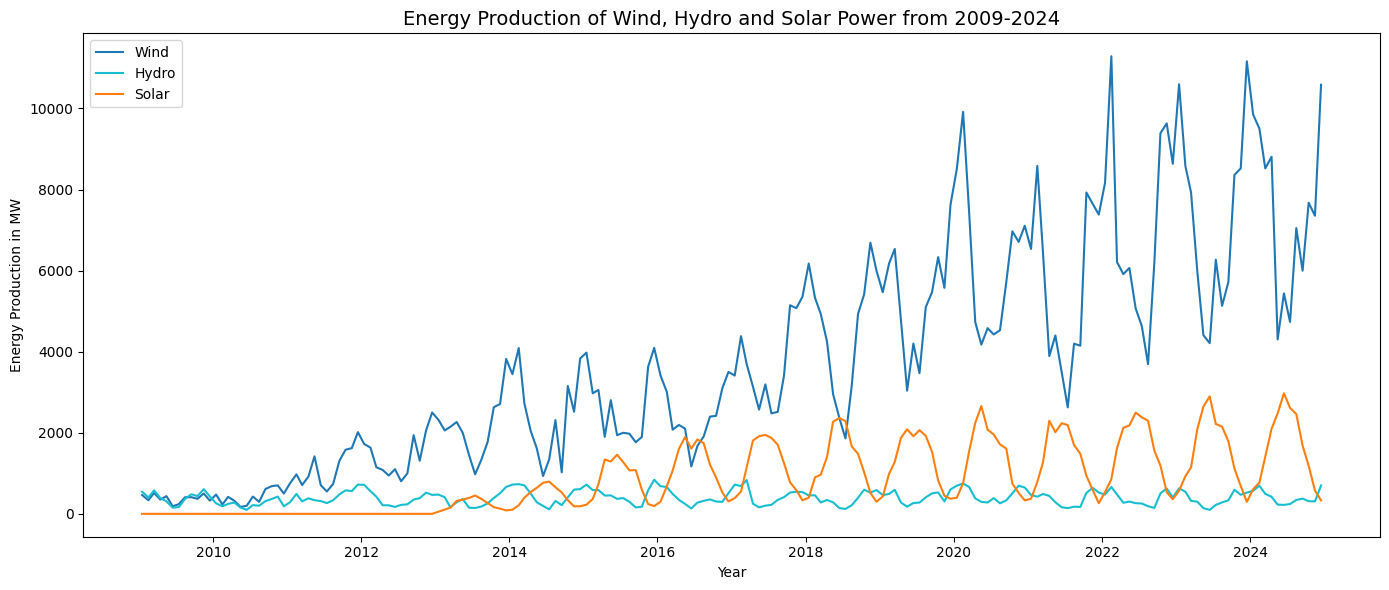

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

#mapping names rather than keeping column names bc i dont want them in all caps
labels = {'WIND': 'Wind', 'HYDRO': 'Hydro', 'SOLAR': 'Solar'}
#wanted all diff colours
colors = {'WIND': 'tab:blue', 'HYDRO': 'tab:cyan', 'SOLAR': 'tab:orange'}

#plotting each renewable source separately
for col in ['WIND', 'HYDRO', 'SOLAR']:
    ax.plot(clean_df['time'], clean_df[col], color=colors[col], label=labels[col])

ax.set_xlabel('Year')
ax.set_ylabel('Energy Production in MW')
ax.set_title('Energy Production of Wind, Hydro and Solar Power from 2009-2024', fontsize=14)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('/content/drive/My Drive/energy_production.png') #saving to my google drive
plt.show()

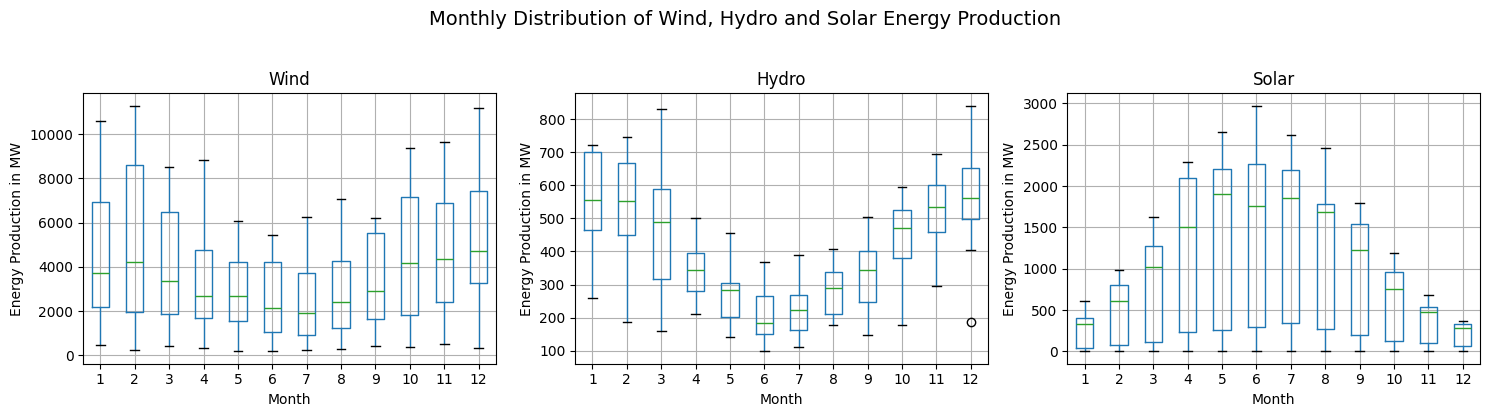

In [ ]:
#getting month from the cleaned df
clean_df['month'] = pd.to_datetime(clean_df['time']).dt.month

#mapping so its not in all caps
labels = {'WIND': 'Wind', 'HYDRO': 'Hydro', 'SOLAR': 'Solar'}

#doing separate box plots for each renewable source
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['WIND', 'HYDRO', 'SOLAR']):
    clean_df.boxplot(column=col, by='month', ax=ax)
    ax.set_title(labels[col])
    ax.set_xlabel('Month')
    ax.set_ylabel('Energy Production in MW')

plt.suptitle('Monthly Distribution of Wind, Hydro and Solar Energy Production', fontsize=14, y=1.03) #title wasn't lining up nicely so moved it up slightly
plt.tight_layout()
plt.savefig('/content/drive/My Drive/monthly_distribution.png', bbox_inches = "tight") #saving to my google drive
#tight layout was still cutting of title for some reason so had to add bbox_inches tight
plt.show()

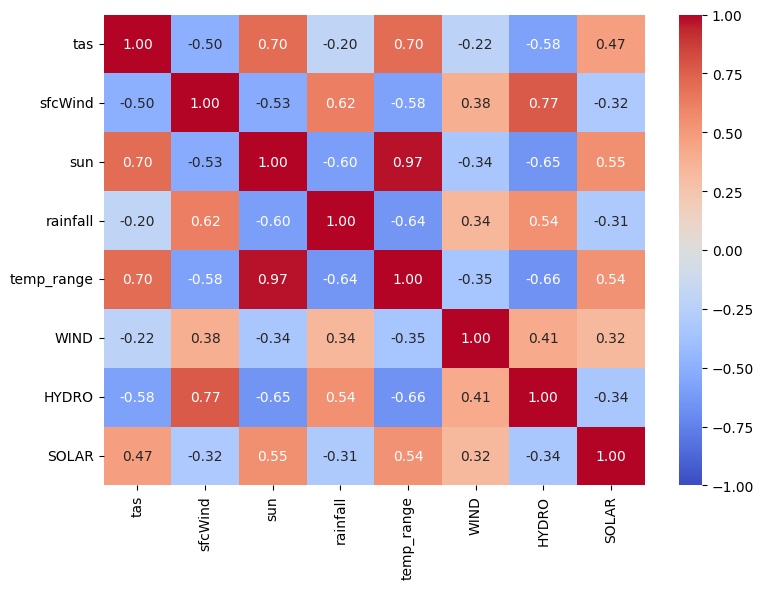

In [ ]:
corr_cols = ['tas', 'sfcWind', 'sun', 'rainfall', 'temp_range', 'WIND', 'HYDRO', 'SOLAR'] #specifying columns i want in the heatmap
corr = clean_df[corr_cols].corr() #producing correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1) #plotting correl in a heatmap to 2 decimal places
#did range -1 to 1 for heatmap colour as there was negatives in this one
plt.tight_layout()
plt.savefig('/content/drive/My Drive/corr_heatmap.png') #saving to my google drive
plt.show()

In [ ]:
for col in ['WIND', 'HYDRO', 'SOLAR']: #calculating skew for each renewable enrrgy source for the histogram plot
    print(clean_df[col].skew())

0.7078627456023577
0.35260185693904933
0.6630568080070116


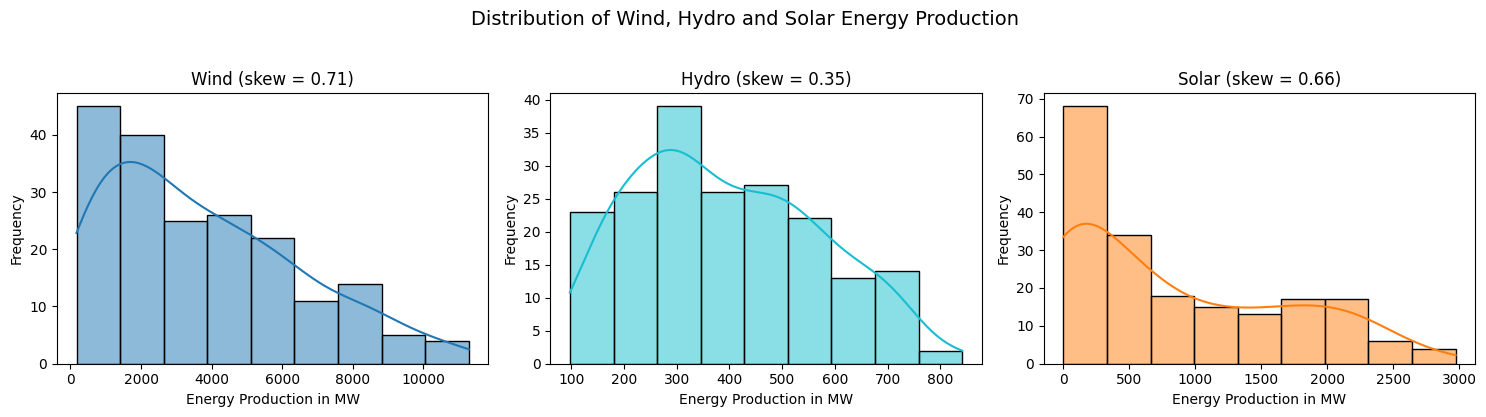

In [ ]:
#mapping so not in all caps
labels = {'WIND': 'Wind', 'HYDRO': 'Hydro', 'SOLAR': 'Solar'}
#same colours as the time series plot of energy production
colors = {'WIND': 'tab:blue', 'HYDRO': 'tab:cyan', 'SOLAR': 'tab:orange'}

#one plot per energy source
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['WIND', 'HYDRO', 'SOLAR']):
    sns.histplot(clean_df[col], kde=True, ax=ax, color=colors[col]) #histogram and kde curve
    ax.set_title(f"{labels[col]} (skew = {clean_df[col].skew():.2f})") #putting skew calculated above to 2 decimal places
    ax.set_xlabel('Energy Production in MW')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Wind, Hydro and Solar Energy Production', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/distribution.png') #saving to google drive
plt.show()

In [ ]:
clean_df.columns

Index(['time', 'tas', 'sfcWind', 'sun', 'rainfall', 'WIND', 'HYDRO', 'SOLAR',
       'month_sin', 'month_cos', 'tas_lag', 'rainfall_lag', 'sun_lag',
       'sfcWind_lag', 'tasmin_lag', 'tasmax_lag', 'incr_seq', 'temp_range',
       'month'],
      dtype='object')

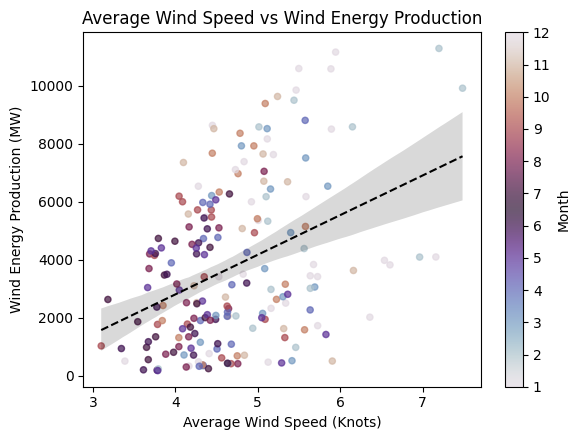

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

#scatter plot of wind v wind production coloured by month
sc = ax.scatter(clean_df['sfcWind'], clean_df['WIND'], c=clean_df['month'], cmap='twilight', alpha=0.7, s=20)
#also plotted linear regression line to give a more clear visual of correlation
sns.regplot(x='sfcWind', y='WIND', data=clean_df, scatter=False, ax=ax,color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'})
ax.set_xlabel('Average Wind Speed (Knots)')
ax.set_ylabel('Wind Energy Production (MW)')
ax.set_title('Average Wind Speed vs Wind Energy Production')

cbar = fig.colorbar(sc, ax=ax) #adding a colour bar to explain the gradient of the scatter points
cbar.set_label('Month')
cbar.set_ticks(range(1, 13)) #laying out the bar by month

plt.tight_layout()
plt.savefig('/content/drive/My Drive/windvwind.png') #saving to google drive
plt.show()

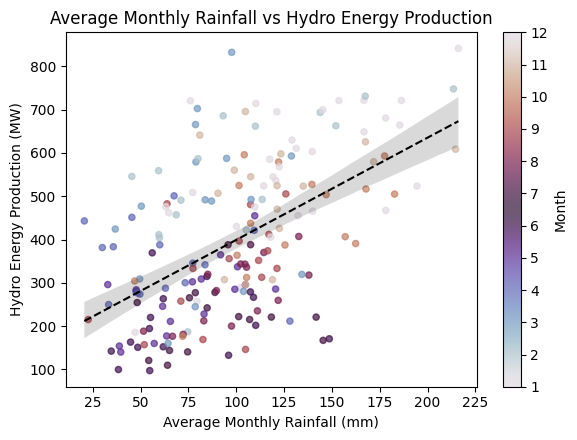

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

#plot of rain v hydro production
sc = ax.scatter(clean_df['rainfall'], clean_df['HYDRO'], c=clean_df['month'], cmap='twilight', alpha=0.7, s=20)
sns.regplot(x='rainfall', y='HYDRO', data=clean_df, scatter=False, ax=ax,color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'}) #added linear regression line
ax.set_xlabel('Average Monthly Rainfall (mm)')
ax.set_ylabel('Hydro Energy Production (MW)')
ax.set_title('Average Monthly Rainfall vs Hydro Energy Production')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Month')
cbar.set_ticks(range(1, 13))

plt.tight_layout()
plt.savefig('/content/drive/My Drive/rainfallvhydro.png')
plt.show()

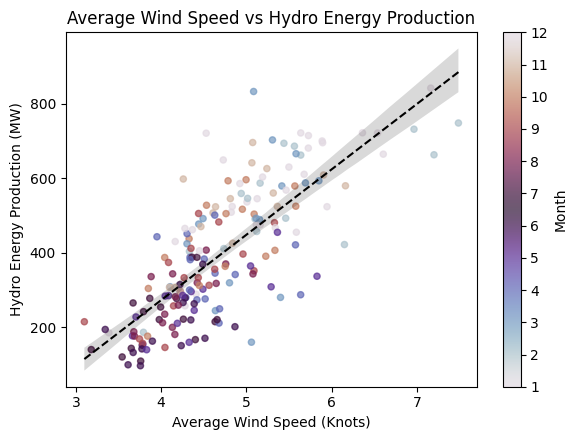

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

sc = ax.scatter(clean_df['sfcWind'], clean_df['HYDRO'], c=clean_df['month'], cmap='twilight', alpha=0.7, s=20)
sns.regplot(x='sfcWind', y='HYDRO', data=clean_df, scatter=False, ax=ax,color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'})
ax.set_xlabel('Average Wind Speed (Knots)')
ax.set_ylabel('Hydro Energy Production (MW)')
ax.set_title('Average Wind Speed vs Hydro Energy Production')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Month')
cbar.set_ticks(range(1, 13))

plt.tight_layout()
plt.savefig('/content/drive/My Drive/windvhydro.png')
plt.show()

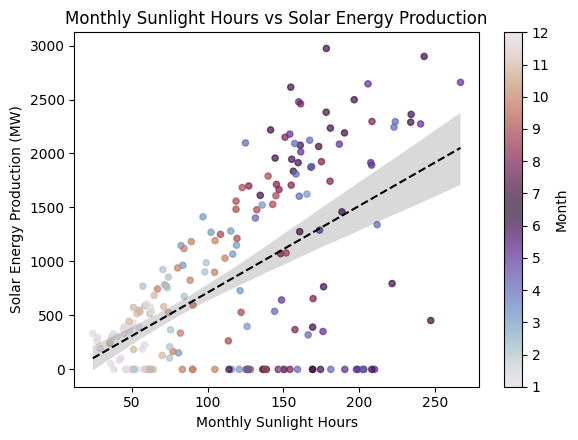

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

sc = ax.scatter(clean_df['sun'], clean_df['SOLAR'], c=clean_df['month'], cmap='twilight', alpha=0.7, s=20)
sns.regplot(x='sun', y='SOLAR', data=clean_df, scatter=False, ax=ax,color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'})
ax.set_xlabel('Monthly Sunlight Hours')
ax.set_ylabel('Solar Energy Production (MW)')
ax.set_title('Monthly Sunlight Hours vs Solar Energy Production')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Month')
cbar.set_ticks(range(1, 13))

plt.tight_layout()
plt.savefig('/content/drive/My Drive/sunvsolar.png')
plt.show()

In [ ]:
import unicodedata
degree = unicodedata.lookup("DEGREE SIGN")

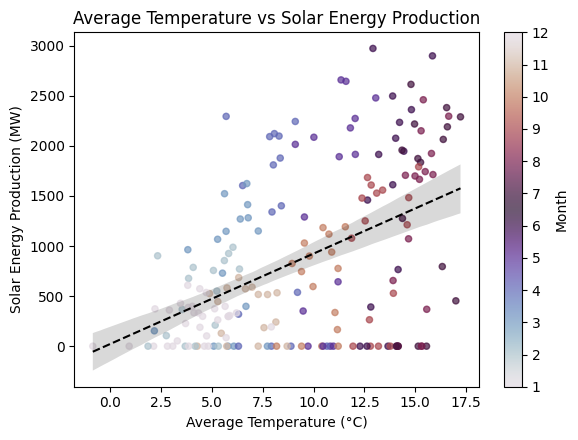

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

sc = ax.scatter(clean_df['tas'], clean_df['SOLAR'], c=clean_df['month'], cmap='twilight', alpha=0.7, s=20)
sns.regplot(x='tas', y='SOLAR', data=clean_df, scatter=False, ax=ax,color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'})
ax.set_xlabel(f'Average Temperature ({degree}C)')
ax.set_ylabel('Solar Energy Production (MW)')
ax.set_title('Average Temperature vs Solar Energy Production')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Month')
cbar.set_ticks(range(1, 13))


plt.tight_layout()
plt.savefig('/content/drive/My Drive/tempvsolar.png')
plt.show()

In [ ]:
neso_df_monthly_filter = neso_df_monthly[neso_df_monthly.index <= '2024-12-31']
neso_df_yearly = neso_df_monthly.resample('YE').mean()
#resampling the percentage share by year for a plot, will reduce noise in the increase in capacity

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
scale = 15

#plotting eeach renewable energy source with bubble size proportional to the perc share of total generation in the uk
ax.scatter(neso_df_yearly.index, neso_df_yearly['WIND_perc'], s=neso_df_yearly['WIND_perc'] * scale, alpha=0.7, label='Wind', color='m')
ax.scatter(neso_df_yearly.index, neso_df_yearly['HYDRO_perc'], s=neso_df_yearly['HYDRO_perc'] * scale, alpha=0.7, label='Hydro', color='darkorange')
ax.scatter(neso_df_yearly.index, neso_df_yearly['SOLAR_perc'], s=neso_df_yearly['SOLAR_perc'] * scale, alpha=0.7, label='Solar', color='c')

ax.set_xlabel('Year')
ax.set_ylabel('Average Percentage of Total Generation (%)')
ax.set_title('Wind, Hydro and Solar Share of UK Electricity Generation Mix by Year')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/My Drive/perc_mix.png') #saving to google drive
plt.show()